# LightGBM Model

In this section, we implement the LightGMB model for phishing website detection.

LightGBM is a gradient boosting framework based on decision trees. It is designed to improve predictive performance by combining multiple weak learners and is well suited for tabular data.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Load Clean Dataset
df = pd.read_csv("../../data/processed-phishing.csv")

In [3]:
# Separate features and target variable
X = df.drop("Result", axis=1)
y = df["Result"]

print(X.shape)
print(y.shape)

(5849, 30)
(5849,)


In [4]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
# Tune LightGBM on train set using CV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "num_leaves": [15, 31, 63],
    "max_depth": [-1, 5, 10],
}

grid = GridSearchCV(
    LGBMClassifier(objective="binary", random_state=42, verbosity=-1),
    param_grid=param_grid,
    cv=skf,
    scoring="accuracy",
    n_jobs=-1,
)
grid.fit(X_train, y_train)
lgbm = grid.best_estimator_

cv_results = cross_validate(
    lgbm,
    X_train,
    y_train,
    cv=skf,
    scoring=["accuracy", "precision", "recall", "f1"],
    n_jobs=-1,
)
print("Best Params:", grid.best_params_)
print(f"CV Accuracy: {cv_results['test_accuracy'].mean():.4f} +/- {cv_results['test_accuracy'].std():.4f}")

# Train best model on full train set and predict test
lgbm.fit(X_train, y_train)
y_pred = lgbm.predict(X_test)

[LightGBM] [Info] Number of positive: 2264, number of negative: 2415
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001248 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 89
[LightGBM] [Info] Number of data points in the train set: 4679, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.483864 -> initscore=-0.064566
[LightGBM] [Info] Start training from score -0.064566


LightGBM Results:

Accuracy: 0.9555555555555556
Precision: 0.9572953736654805
Recall: 0.950530035335689
F1 Score: 0.9539007092198581

Confusion Matrix:
[[580  24]
 [ 28 538]]


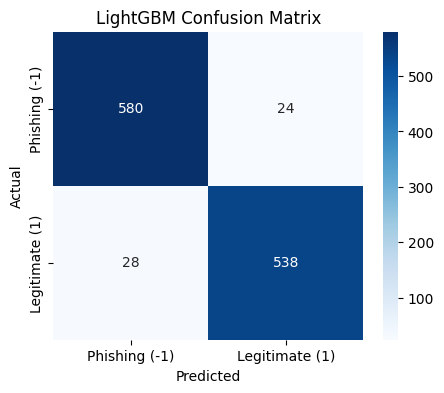

In [6]:
# Evaluate the tuned model
print("LightGBM (Tuned with CV) Results:")
print()

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, pos_label=1))
print("Recall:", recall_score(y_test, y_pred, pos_label=1))
print("F1 Score:", f1_score(y_test, y_pred, pos_label=1))
print()

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Phishing (-1)", "Legitimate (1)"],
    yticklabels=["Phishing (-1)", "Legitimate (1)"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LightGBM Confusion Matrix")

plt.show()

## Results

The LightGBM model achieved strong performance on the phishing website detection task.

- Accuracy: 0.9556
- Precision: 0.9573
- Recall: 0.9505
- F1 Score: 0.9539

These results indicate that the model performs well in distinguishing phishing websites from legitimate ones.

The confusion matrix shows that the model makes relatively few misclassifications.
It correctly classifies most phishing and legitimate websites, while keeping both false positives and false negatives low. This suggests that the model is both accurate and balanced in its predictions.

In [7]:
# Check for overfitting
y_train_pred = lgbm.predict(X_train)

print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_pred))

Train Accuracy: 0.9807651207522975
Test Accuracy: 0.9555555555555556


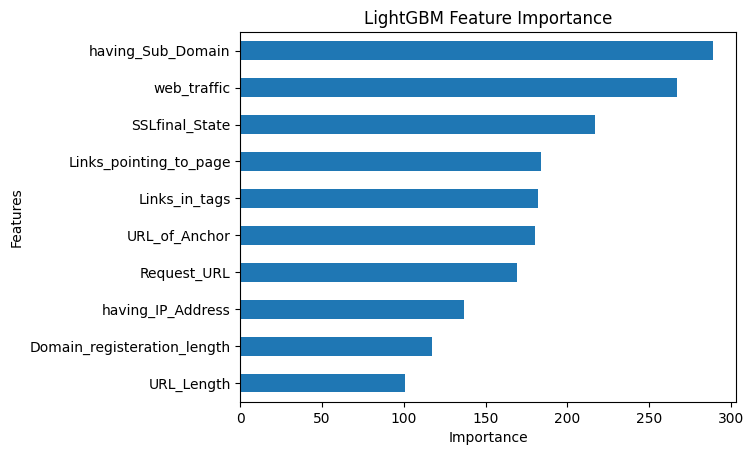


Top 10 Important Features:
                        Feature  Importance
6             having_Sub_Domain         289
25                  web_traffic         267
7                SSLfinal_State         217
28       Links_pointing_to_page         184
14                Links_in_tags         182
13                URL_of_Anchor         180
12                  Request_URL         169
0             having_IP_Address         137
8   Domain_registeration_length         117
1                    URL_Length         101


In [8]:
# Feature Importance
importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": lgbm.feature_importances_
}).sort_values(by="Importance", ascending=False)

feat_importance_lgbm = pd.Series(lgbm.feature_importances_, index=X.columns)
feat_importance_lgbm = feat_importance_lgbm.sort_values(ascending=False)

feat_importance_lgbm.head(10).plot(kind='barh')
plt.title("LightGBM Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.gca().invert_yaxis()
plt.show()

print()
print("Top 10 Important Features:")
print(importances.head(10))

## Feature Analysis

LightGBM provides feature importance scores based on how frequently and effectively features are used in decision tree splits.

The most important features include:
- having_Sub_Domain
- web_traffic
- SSLfinal_State
- Links_pointing_to_page